**Chapter 13 – Processing Sequences Using RNNs and CNNs**

_This notebook contains all the sample code and solutions to the exercises in chapter 13._

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-mlp/blob/main/13_processing_sequences_using_rnns_and_cnns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-mlp/blob/main/13_processing_sequences_using_rnns_and_cnns.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Setup

This project requires Python 3.10 or above:

In [ ]:
import sys

assert sys.version_info >= (3, 10)

Are we using Colab or Kaggle?

In [ ]:
IS_COLAB = "google.colab" in sys.modules
IS_KAGGLE = "kaggle_secrets" in sys.modules

If using Colab, the TorchMetrics library is not pre-installed so we must install it manually:

In [ ]:
if IS_COLAB:
    %pip install -q torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 61.5 MB/s eta 0:00:00


We also need PyTorch ≥ 2.6.0:

In [ ]:
from packaging.version import Version
import torch

assert Version(torch.__version__) >= Version("2.6.0")

This chapter can be very slow without a hardware accelerator, so if we can find one, let's use it:

In [ ]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cuda'

Let's issue a warning if there's no hardware accelerator available:

In [ ]:
if device == "cpu":
    print("Neural nets can be very slow without a hardware accelerator.")
    if IS_COLAB:
        print("Go to Runtime > Change runtime and select a GPU hardware "
              "accelerator.")
    if IS_KAGGLE:
        print("Go to Settings > Accelerator and select GPU.")

As we did in earlier chapters, let's define the default font sizes to make the figures prettier:

In [ ]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

# Training RNNs

## Forecasting a Time Series

Let's download the ridership data from the ageron/data project. It originally comes from Chicago's Transit Authority, and was downloaded from the [Chicago's Data Portal](https://homl.info/ridership).

In [ ]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def download_and_extract_ridership_data():
    tarball_path = Path("datasets/ridership.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/ridership.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter="data")

download_and_extract_ridership_data()

Now let's clean up the data a bit:

In [ ]:
import pandas as pd
from pathlib import Path

path = Path("datasets/ridership/CTA_-_Ridership_-_Daily_Boarding_Totals.csv")
df = pd.read_csv(path, parse_dates=["service_date"])
df.columns = ["date", "day_type", "bus", "rail", "total"]  # shorter names
df = df.sort_values("date").set_index("date")
df = df.drop("total", axis=1)  # no need for total, it's just bus + rail
df = df.drop_duplicates()  # remove duplicated months (2011-10 and 2014-07)

In [ ]:
df.head()

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917


Let's look at the first few months of 2019 (note that Pandas treats the range boundaries as inclusive):

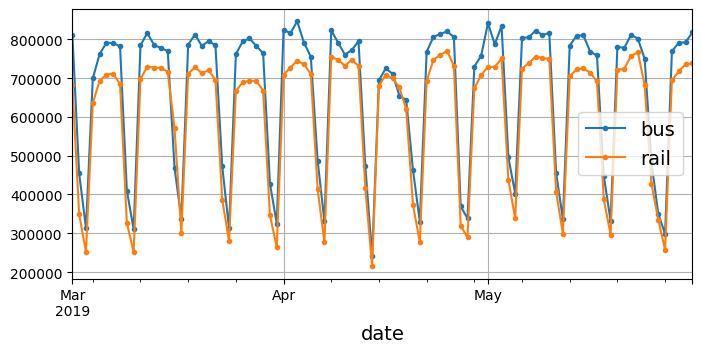

In [ ]:
import matplotlib.pyplot as plt

df["2019-03":"2019-05"].plot(grid=True, marker=".", figsize=(8, 3.5))
plt.show()

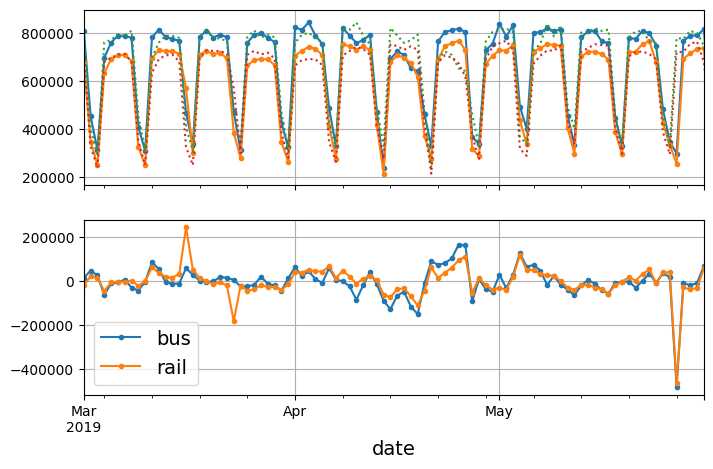

In [ ]:
diff_7 = df[["bus", "rail"]].diff(7)["2019-03":"2019-05"]

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 5))
df.plot(ax=axs[0], legend=False, marker=".")  # original time series
df.shift(7).plot(ax=axs[0], grid=True, legend=False, linestyle=":")  # lagged
diff_7.plot(ax=axs[1], grid=True, marker=".")  # 7-day difference time series
axs[0].set_ylim([170_000, 900_000])  # extra code – beautifies the plot

plt.show()

In [ ]:
class TimeSeriesDataset(torch.utils.data.Dataset):
  def __init__(self, X, window_size):
    self.X = X
    self.window_size = window_size

  def __getitem__(self, i):
    inputs = self.X[i:i + self.window_size]
    output = self.X[i + self.window_size:i + self.window_size + 1]
    return inputs, output

  def __len__(self):
    return len(self.X) - self.window_size - 1



In [ ]:
# df[["rail"]]["2016-01":"2018-12"].values.shape

In [ ]:
from torch.utils.data import DataLoader

window_length = 54
rail_train = torch.FloatTensor(df[["rail"]]["2016-01":"2018-12"].values / 1e6)
rail_valid = torch.FloatTensor(df[["rail"]]["2019-01":"2019-05"].values / 1e6)
rail_test = torch.FloatTensor(df[["rail"]]["2019-06":].values / 1e6)


train_set = TimeSeriesDataset(rail_train, window_length)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
valid_set = TimeSeriesDataset(rail_valid, window_length)
valid_loader = DataLoader(valid_set, batch_size=32)
test_set = TimeSeriesDataset(rail_test, window_length)
test_loader = DataLoader(test_set, batch_size=32)

In [ ]:
for X, y in train_loader:
  print(X.shape, y.shape)
  break

torch.Size([32, 54, 1]) torch.Size([32, 1, 1])


In [ ]:
def mae(y_preds, y_gt):
  assert y_preds.shape == y_gt.shape
  return (y_preds - y_gt).abs().mean()


In [ ]:
def mse(y_preds, y_gt):
  assert y_preds.shape == y_gt.shape
  return ((y_preds - y_gt) ** 2).mean()

In [ ]:
from torch import nn

class PrevValueModel(nn.Module):
  def __init__(self, shift=1):
    super().__init__()
    self.shift = shift

  def forward(self, X):       # BS x Seq_len x N_FEATS
    return X[:, -self.shift].reshape(X.shape[0], 1, X.shape[2]) # BS x Seq_len x N_FEATS


In [ ]:
prev_val_model = PrevValueModel(shift=7)

preds = prev_val_model(X)

NameError: name 'X' is not defined

In [ ]:
def evaluate_model(model, dataloader):
  with torch.no_grad():
    total_loss = 0
    batch_count = 0
    for X, y in dataloader:
      X = X.cuda()
      y = y.cuda()
      preds = model(X)
      loss = mae(preds, y)
      total_loss += loss.item()
      batch_count += 1
  return total_loss/batch_count * 1e6


evaluate_model(prev_val_model, valid_loader), evaluate_model(prev_val_model, train_loader)

(42103.73138387998, 54130.8821376526)

In [ ]:
prev_val_model_1 = PrevValueModel(shift=1)
evaluate_model(prev_val_model_1, valid_loader)

130597.98876444498

In [ ]:
class MLP(nn.Module):
  def __init__(self, n_steps_inpt, n_feats, n_steps_out, n_preds_per_step):
    super().__init__()
    self.n_steps_out = n_steps_out
    self.n_preds_per_step = n_preds_per_step
    self.fl = nn.Flatten()
    self.l1 = nn.Linear(n_steps_inpt * n_feats, n_steps_out * n_preds_per_step)

  def forward(self, X):
    X = self.fl(X)
    X = self.l1(X)
    return X.reshape(X.shape[0], self.n_steps_out, self.n_preds_per_step)


In [ ]:
mlp_model = MLP(n_steps_inpt=54, n_feats=1, n_steps_out=1, n_preds_per_step=1)
mlp_model = mlp_model.cuda()

In [ ]:
from torch.optim import Adam
opt = Adam(mlp_model.parameters())

In [ ]:
from tqdm import tqdm

def train_model(model, opt, train_loader, valid_loader, n_epochs=100):
  epochs_losses = []
  epochs_train_metric = []
  epochs_val_metric = []
  pbar = tqdm(range(n_epochs))
  for e in pbar:
    losses = []
    for X, y in train_loader:
      X = X.cuda()
      y = y.cuda()
      preds = model(X)
      loss = mse(preds, y)
      loss.backward()
      losses.append(loss.item())
      opt.step()
      opt.zero_grad()
    epochs_losses.append(sum(losses)/len(losses))
    epochs_train_metric.append(evaluate_model(model, train_loader))
    epochs_val_metric.append(evaluate_model(model, valid_loader))
    pbar.set_description(f"train_loss: {epochs_losses[-1]:0.03f}, train_metric: {epochs_train_metric[-1]:0.03f}, val_metric: {epochs_val_metric[-1]:0.03f}")
  return epochs_losses, epochs_train_metric, epochs_val_metric


In [ ]:
train_model(mlp_model, opt, train_loader, valid_loader, 500);

train_loss: 0.005, train_metric: 40223.602, val_metric: 38578.254:  66%|██████▌   | 328/500 [00:22<00:11, 14.36it/s]


KeyboardInterrupt: 

In [ ]:
class RecurrentNeuronNoActivation(nn.Module):
  def __init__(self, n_feats):
    super().__init__()
    self.neuron = nn.Linear(n_feats + 1, 1)

  def forward(self, X): # X: [BS, n_steps, n_feats]
    y = torch.zeros((X.shape[0], 1))

    for i in range(X.shape[1]):
      X_step = torch.cat([X[:, i], y], dim=-1)
      y = self.neuron(X_step)

    return y.reshape(X.shape[0], 1, 1)

rnn = RecurrentNeuronNoActivation(n_feats=1)

In [ ]:

opt = Adam(rnn.parameters(), lr=0.001)

In [ ]:
train_model(rnn, opt, train_loader, valid_loader, 500);

train_loss: 0.024, train_metric: 128602.153, val_metric: 123497.737:  67%|██████▋   | 337/500 [01:43<00:49,  3.27it/s]


KeyboardInterrupt: 

In [ ]:
class RNN(nn.Module):
  def __init__(self, n_feats, hidden_dims):
    super().__init__()
    self.hidden_dims = hidden_dims
    self.layer = nn.Linear(n_feats + hidden_dims, hidden_dims)
    self.output = nn.Linear(hidden_dims, 1)

  def forward(self, X): # X: [BS, n_steps, n_feats]
    y = torch.zeros((X.shape[0], self.hidden_dims)).to(X.device)

    for i in range(X.shape[1]):
      X_step = torch.cat([X[:, i], y], dim=-1)
      y = self.layer(X_step)
      y = torch.tanh(y)

    y = self.output(y)
    return y.reshape(X.shape[0], 1, 1)

rnn = RNN(n_feats=1, hidden_dims=32).cuda()

In [ ]:
opt = Adam(rnn.parameters(), lr=0.001)


In [ ]:
epochs_losses, epochs_train_metric, epochs_val_metric = train_model(rnn, opt, train_loader, valid_loader, 500)

train_loss: 0.005, train_metric: 37814.006, val_metric: 31892.454: 100%|██████████| 500/500 [05:01<00:00,  1.66it/s]


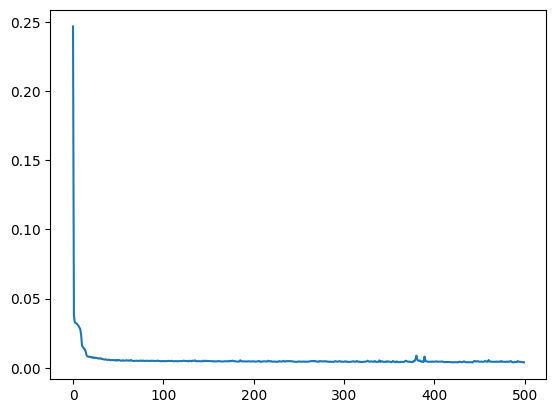

In [ ]:
plt.plot(epochs_losses)

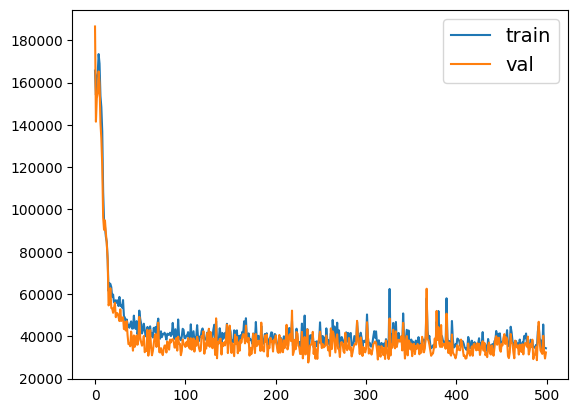

In [ ]:
plt.plot(epochs_train_metric, label="train")
plt.plot(epochs_val_metric, label="val")
plt.legend()

In [ ]:
# sum(epochs_val_metric[-100:])/100

In [ ]:
class MultiLayerRNN(nn.Module):
  def __init__(self, n_feats, hidden_dims, n_layers):
    super().__init__()
    self.rnn = nn.RNN(n_feats, hidden_dims, n_layers, batch_first=True)
    self.output = nn.Linear(hidden_dims, 1)

  def forward(self, X):
    y, _ = self.rnn(X)
    y = y[:, -1]
    y = self.output(y)
    return y.reshape(X.shape[0], 1, -1)


In [ ]:
rnn_ml = MultiLayerRNN(1, 32, 1).cuda()

In [ ]:
opt = Adam(rnn_ml.parameters())

In [ ]:
epochs_losses, epochs_train_metric, epochs_val_metric = train_model(rnn_ml, opt, train_loader, valid_loader, 500)

train_loss: 0.004, train_metric: 37332.140, val_metric: 31148.363: 100%|██████████| 500/500 [00:52<00:00,  9.47it/s]


In [ ]:
sum(epochs_val_metric[-100:])/100

33560.97767750422

In [ ]:
evaluate_model(mlp_model, valid_loader)

69911.4017188549